# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import gaussian_kde

In [2]:
file_path = "../1.DATASET/cmi_internet.csv"
df1=pd.read_csv(file_path)
df1.head(9)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.50,112.2,...,1.0,2.0,1.0,34.0,Summer,40.0,56.0,Spring,0.0,1.0
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,4.0,1.0,0.0,20.0,Winter,27.0,40.0,Fall,3.0,0.0
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,NaN,NaN,NaN,NaN,Spring,39.0,55.0,Fall,2.0,0.0
8,8,Summer,15,0,Spring,65.0,Spring,NaN,55.00,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.0,0.0


In [3]:
df= df1.copy()

In [4]:
df.head(9)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.50,112.2,...,1.0,2.0,1.0,34.0,Summer,40.0,56.0,Spring,0.0,1.0
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,4.0,1.0,0.0,20.0,Winter,27.0,40.0,Fall,3.0,0.0
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,NaN,NaN,NaN,NaN,Spring,39.0,55.0,Fall,2.0,0.0
8,8,Summer,15,0,Spring,65.0,Spring,NaN,55.00,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,2.0,0.0


In [5]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

In [6]:
df["BIA-BIA_Fat"].describe()

count    6636.000000
mean       14.102183
std       194.202424
min     -8745.080000
25%        10.636588
50%        16.174600
75%        28.521911
max       153.820000
Name: BIA-BIA_Fat, dtype: float64

In [7]:
df["Physical-Weight"].describe()

count    7641.000000
mean       84.428737
std        40.218441
min         0.000000
25%        55.200000
50%        75.000000
75%       107.000000
max       315.000000
Name: Physical-Weight, dtype: float64

IndexError: index 9 is out of bounds for axis 0 with size 9

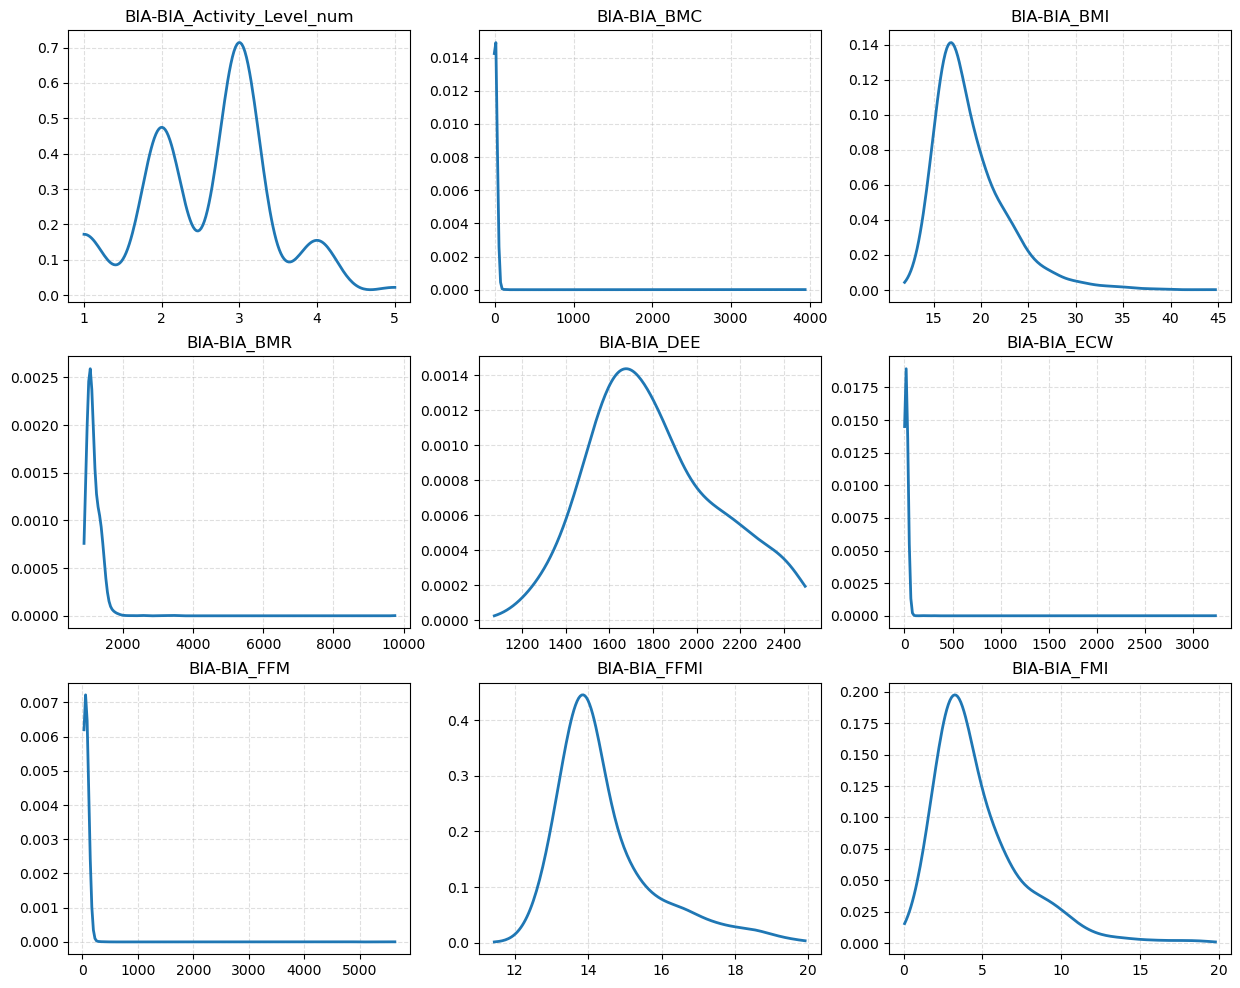

In [ ]:
cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW'
]

fig, ax = plt.subplots(3, 3, figsize=(15, 12))
ax = ax.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna().values
    kde = gaussian_kde(data, bw_method=0.3)

    x_vals = np.linspace(data.min(), data.max(), 200)

    ax[i].plot(x_vals, kde(x_vals), linewidth=2)
    ax[i].set_title(col)
    ax[i].grid(True, linestyle='--', alpha=0.4)

for j in range(len(cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()


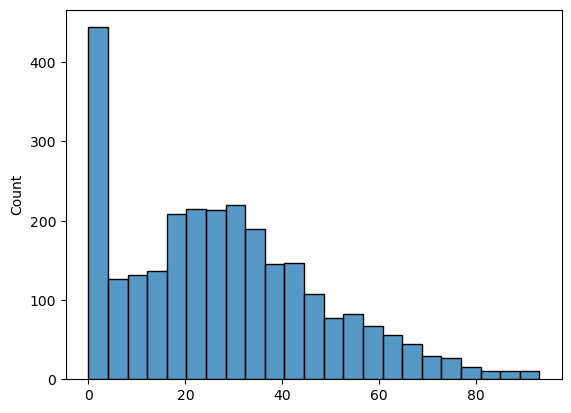

In [6]:

sns.histplot(df["PCIAT-PCIAT_Total"])
plt.xlabel("")
plt.show()

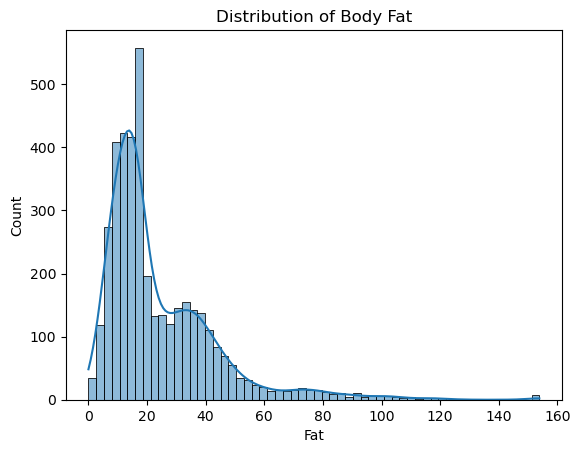

In [ ]:
df = df.loc[df["BIA-BIA_Fat"] >= 0, :]
sns.histplot(df["BIA-BIA_Fat"], kde=True)
plt.title("Distribution of Body Fat")
plt.xlabel("Fat")
plt.show()


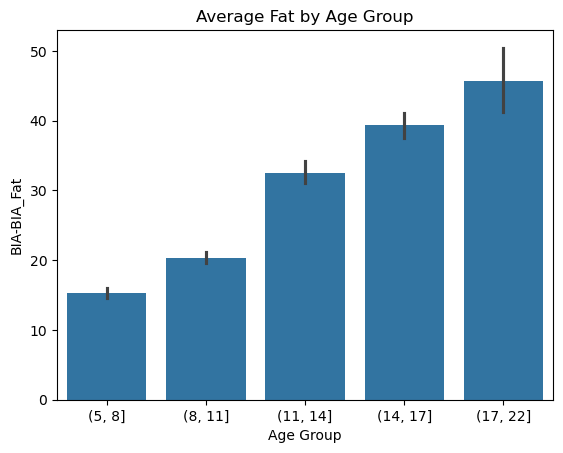

In [28]:
df["Age Group"] = pd.cut(df["Basic_Demos-Age"], bins=[5,8,11,14,17,22])
sns.barplot(data=df, x="Age Group", y="BIA-BIA_Fat")
plt.title("Average Fat by Age Group")
plt.show()

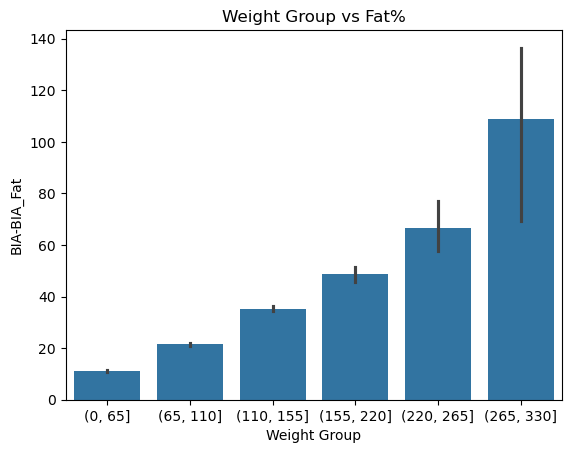

In [10]:
df["Weight Group"] = pd.cut(df["Physical-Weight"], bins=[0,65,110,155,220,265,330]) #in kg 0 30 50 70 100 120 150

sns.barplot(data=df, x="Weight Group", y="BIA-BIA_Fat")
plt.title("Weight Group vs Fat%")
plt.show()


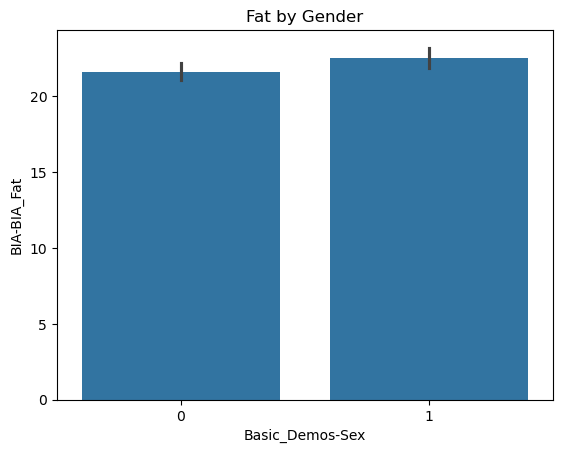

In [11]:
sns.barplot(data=df, x="Basic_Demos-Sex", y="BIA-BIA_Fat")
plt.title("Fat by Gender")
plt.show()

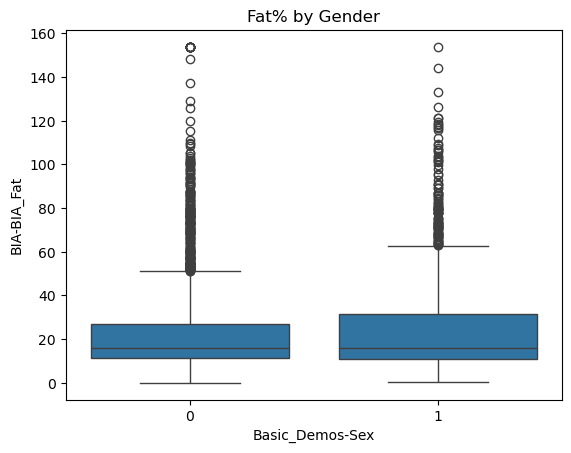

In [12]:
sns.boxplot(data=df, x="Basic_Demos-Sex", y="BIA-BIA_Fat")
plt.title("Fat% by Gender")
plt.show()

In [13]:
df = df.loc[(df["BIA-BIA_TBW"] >= 30) & (df["BIA-BIA_TBW"] <= 130), :] #Inside normal range

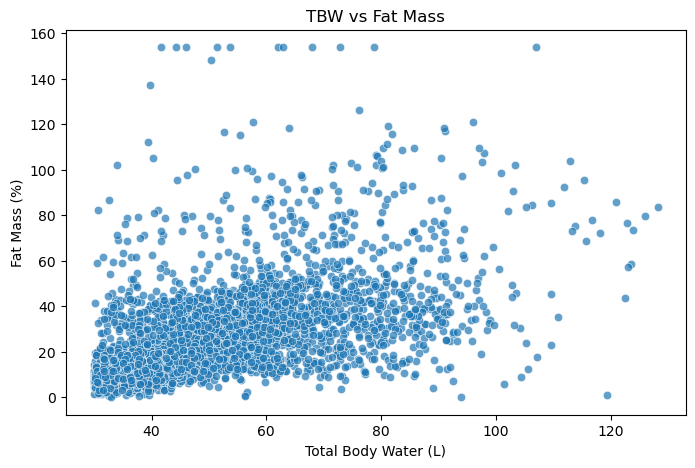

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="BIA-BIA_TBW",
    y="BIA-BIA_Fat",
    alpha=0.7
)
plt.title("TBW vs Fat Mass")
plt.xlabel("Total Body Water (L)")
plt.ylabel("Fat Mass (%)")
plt.show()


In [50]:
cols = [
   'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW'
]

df[cols].describe()

,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW
count,2488.000000,2484.000000,2491.000000,2488.000000,2733.000000,2501.000000,2475.000000,2733.000000,2733.000000,2733.000000,2472.000000,2456.000000,2492.000000,2489.000000,2476.000000,2733.000000
mean,2.596463,6.793769,18.930602,1160.866611,1808.253975,19.255299,70.789616,14.433824,4.723653,21.884960,1.697006,29.536405,23.471203,63.956433,31.528143,45.618444
std,0.865932,83.844698,3.861122,260.327619,292.979002,65.238777,173.858730,1.337633,2.881134,16.890555,0.620719,10.664222,120.624449,109.985433,60.475724,12.511261
min,1.000000,-6.903170,11.926500,888.545000,1073.450000,1.789450,32.545066,11.443200,0.066924,0.026117,1.000000,14.489000,5.856400,30.883779,12.726700,30.023100
25%,2.000000,3.298567,16.308751,1026.832500,1600.070000,11.963500,50.849892,13.592188,2.794570,10.414800,1.000000,24.520552,14.115883,47.432600,22.486900,35.886900
50%,3.000000,4.203405,17.868061,1103.934930,1760.800000,15.288100,58.806284,14.056474,3.823300,16.174600,2.000000,27.906850,17.028332,55.244800,26.720140,42.092500
75%,3.000000,5.263967,20.601641,1268.180105,2005.582082,22.228800,75.475835,14.907669,5.873900,30.170800,2.000000,32.199782,21.358136,70.926100,35.838775,53.301300
max,5.000000,3938.776052,44.733800,9752.170707,2497.547708,3233.000000,5628.732828,19.912700,19.765761,153.820000,3.000000,392.842920,3108.170000,4683.710000,2964.330263,105.478556


In [54]:
df = df.loc[(df["BIA-BIA_TBW"] >= 30) & (df["BIA-BIA_TBW"] <= 150), :]
df = df.loc[(df["BIA-BIA_SMM"] >= 10) & (df["BIA-BIA_SMM"] <= 100), :]
df = df.loc[(df["BIA-BIA_LST"] >= 30) & (df["BIA-BIA_LST"] <= 150), :]
df = df.loc[(df["BIA-BIA_LDM"] >= 0) & (df["BIA-BIA_LDM"] <= 50), :]
df = df.loc[(df["BIA-BIA_ICW"] >= 20) & (df["BIA-BIA_ICW"] <= 70), :]
df = df.loc[(df["BIA-BIA_FFM"] >= 30) & (df["BIA-BIA_FFM"] <= 200), :]
df = df.loc[(df["BIA-BIA_ECW"] >= 1) & (df["BIA-BIA_ECW"] <= 60), :]
df = df.loc[(df["BIA-BIA_BMR"] >= 800) & (df["BIA-BIA_BMR"] <= 2000), :]
df = df.loc[(df["BIA-BIA_BMI"] >= 15) & (df["BIA-BIA_BMI"] <= 40), :]
df = df.loc[(df["BIA-BIA_BMC"] >= 0) & (df["BIA-BIA_BMC"] <= 12), :]
df = df.loc[(df["BIA-BIA_DEE"] >= 0) & (df["BIA-BIA_DEE"] <= 2500), :]
df = df.loc[(df["BIA-BIA_FMI"] >= 0) & (df["BIA-BIA_FMI"] <= 20), :]
df = df.loc[(df["BIA-BIA_FFMI"] >= 0) & (df["BIA-BIA_FFMI"] <= 20), :]

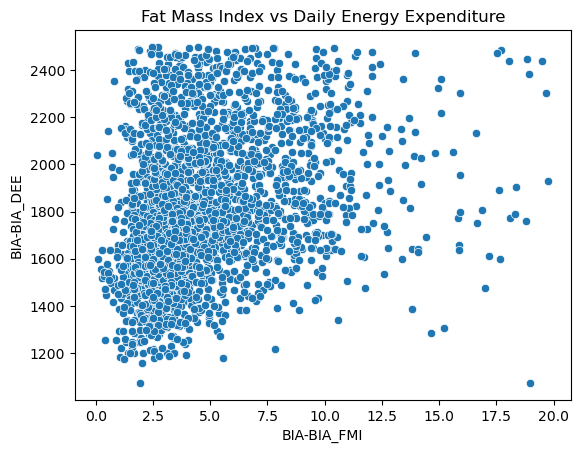

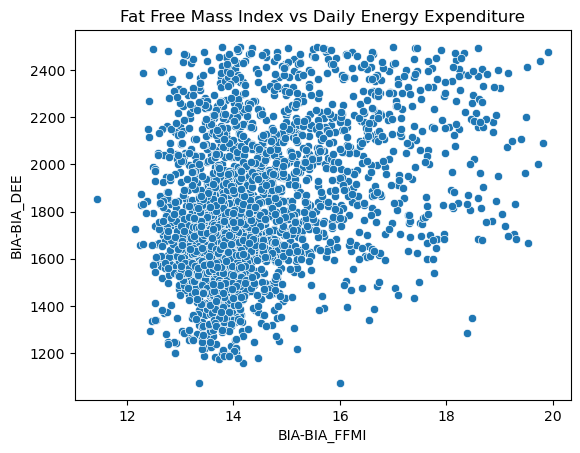

In [37]:
sns.scatterplot(data=df, x="BIA-BIA_FMI", y="BIA-BIA_DEE")
plt.title("Fat Mass Index vs Daily Energy Expenditure")
plt.show()

sns.scatterplot(data=df, x="BIA-BIA_FFMI", y="BIA-BIA_DEE")
plt.title("Fat Free Mass Index vs Daily Energy Expenditure")
plt.show()

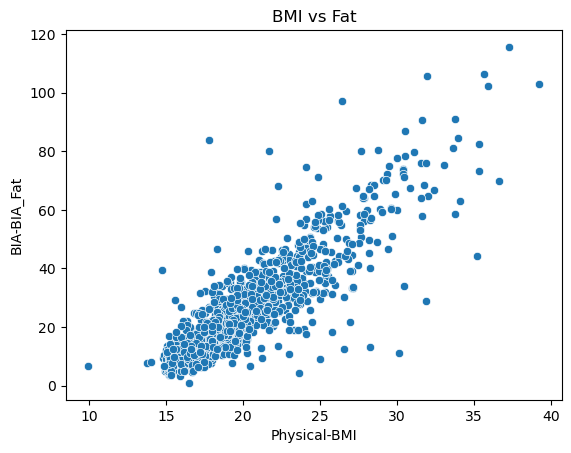

In [55]:
sns.scatterplot(data=df, x="Physical-BMI", y="BIA-BIA_Fat")
plt.title("BMI vs Fat")
plt.show()

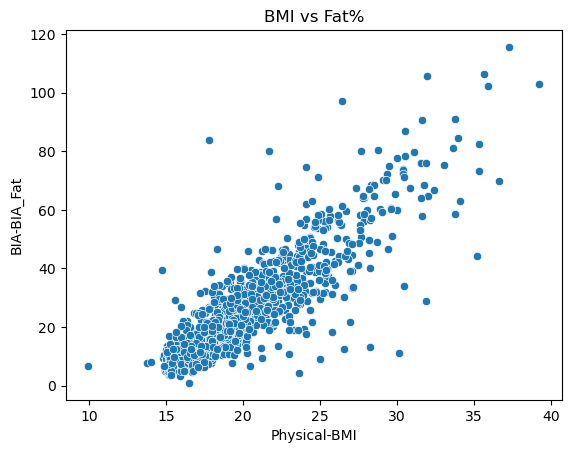

In [56]:
sns.scatterplot(data=df, x="Physical-BMI", y="BIA-BIA_Fat")
plt.title("BMI vs Fat%")
plt.show()

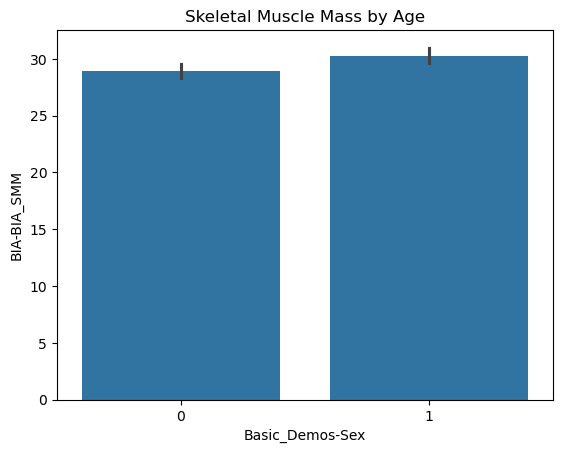

In [ ]:
sns.barplot(data=df, x="Basic_Demos-Sex", y="BIA-BIA_SMM")
plt.title("Skeletal Muscle Mass by Age") 
plt.show()

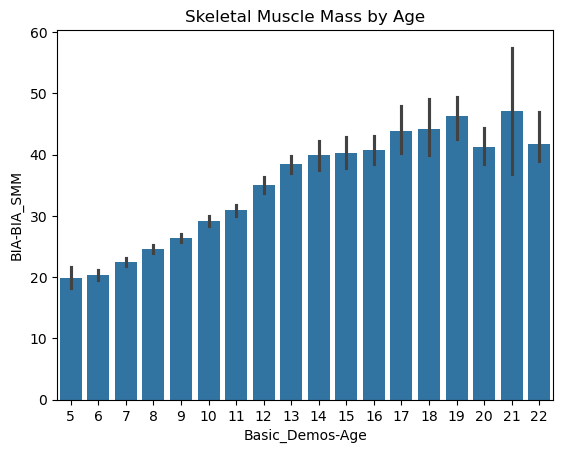

In [59]:
sns.barplot(data=df, x="Basic_Demos-Age", y="BIA-BIA_SMM")
plt.title("Skeletal Muscle Mass by Age") #a bit  strange that at 19 is so high and at 20.. is not that much
plt.show()

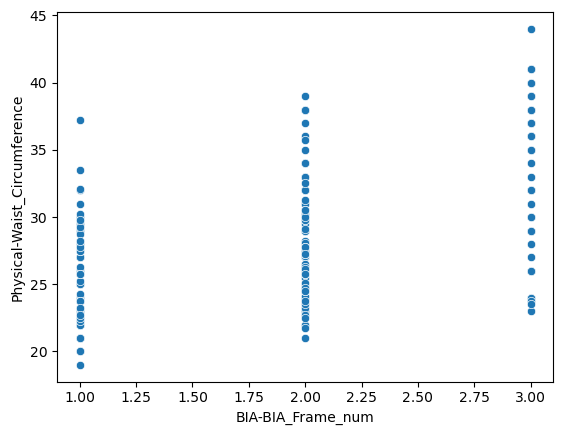

In [60]:
sns.scatterplot(data=df, x="BIA-BIA_Frame_num", y="Physical-Waist_Circumference")
plt.show()

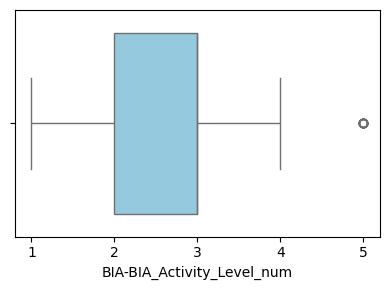

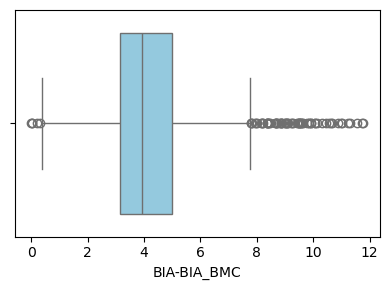

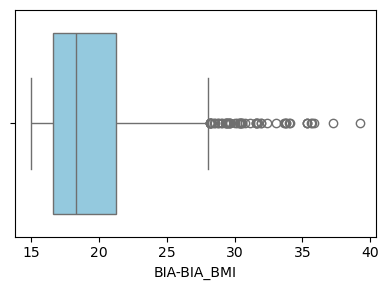

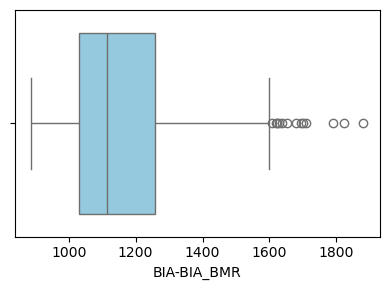

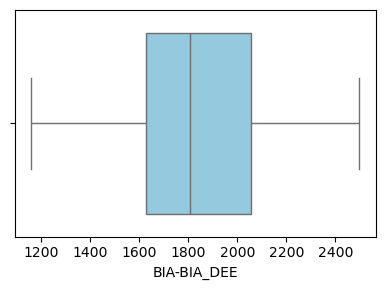

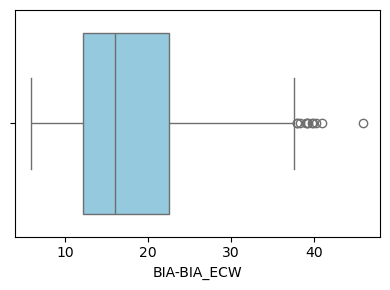

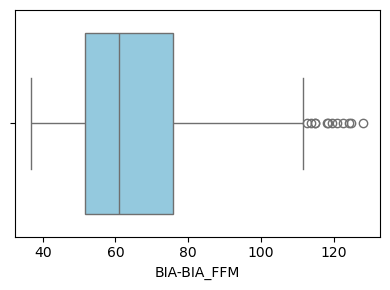

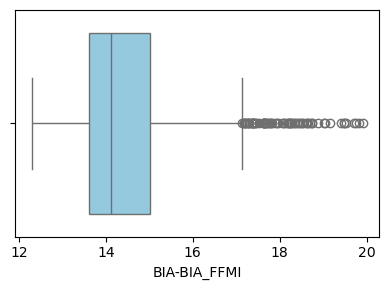

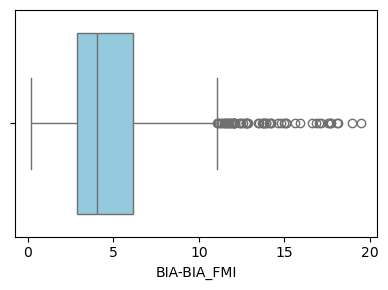

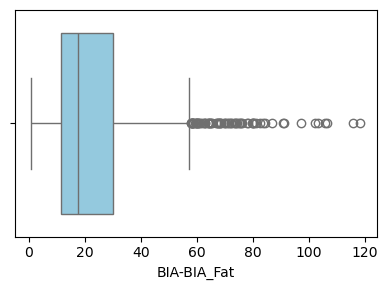

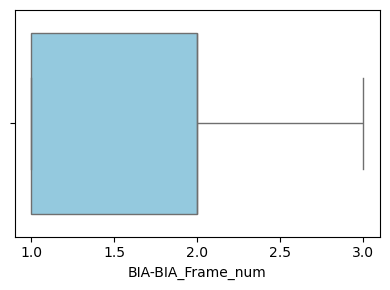

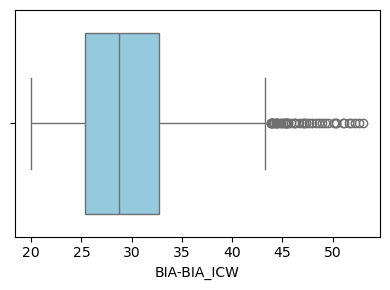

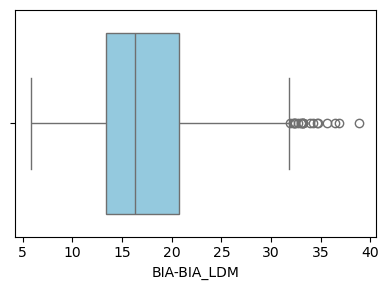

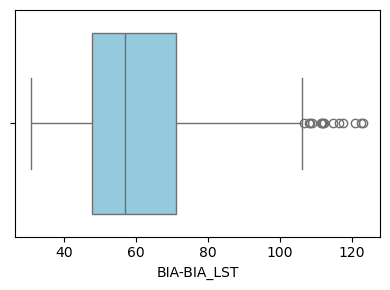

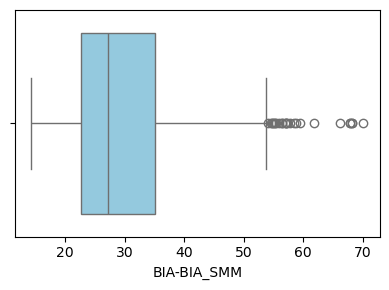

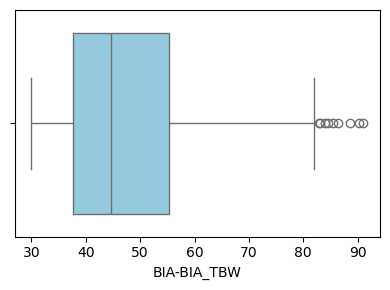

In [57]:
bia_cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
    'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
    'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
    'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
    'BIA-BIA_TBW'
]
for col in bia_cols:
    plt.figure(figsize=(4, 3))
    sns.boxplot(x=df[col], color="skyblue")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    

C:\Users\ESTER\AppData\Local\Temp\ipykernel_1672\2497571878.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ESTER\AppData\Local\Temp\ipykernel_1672\2497571878.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ESTER\AppData\Local\Temp\ipykernel_1672\2497571878.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ESTER\AppData\Local\Temp\ipykernel_1672\2497571878.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

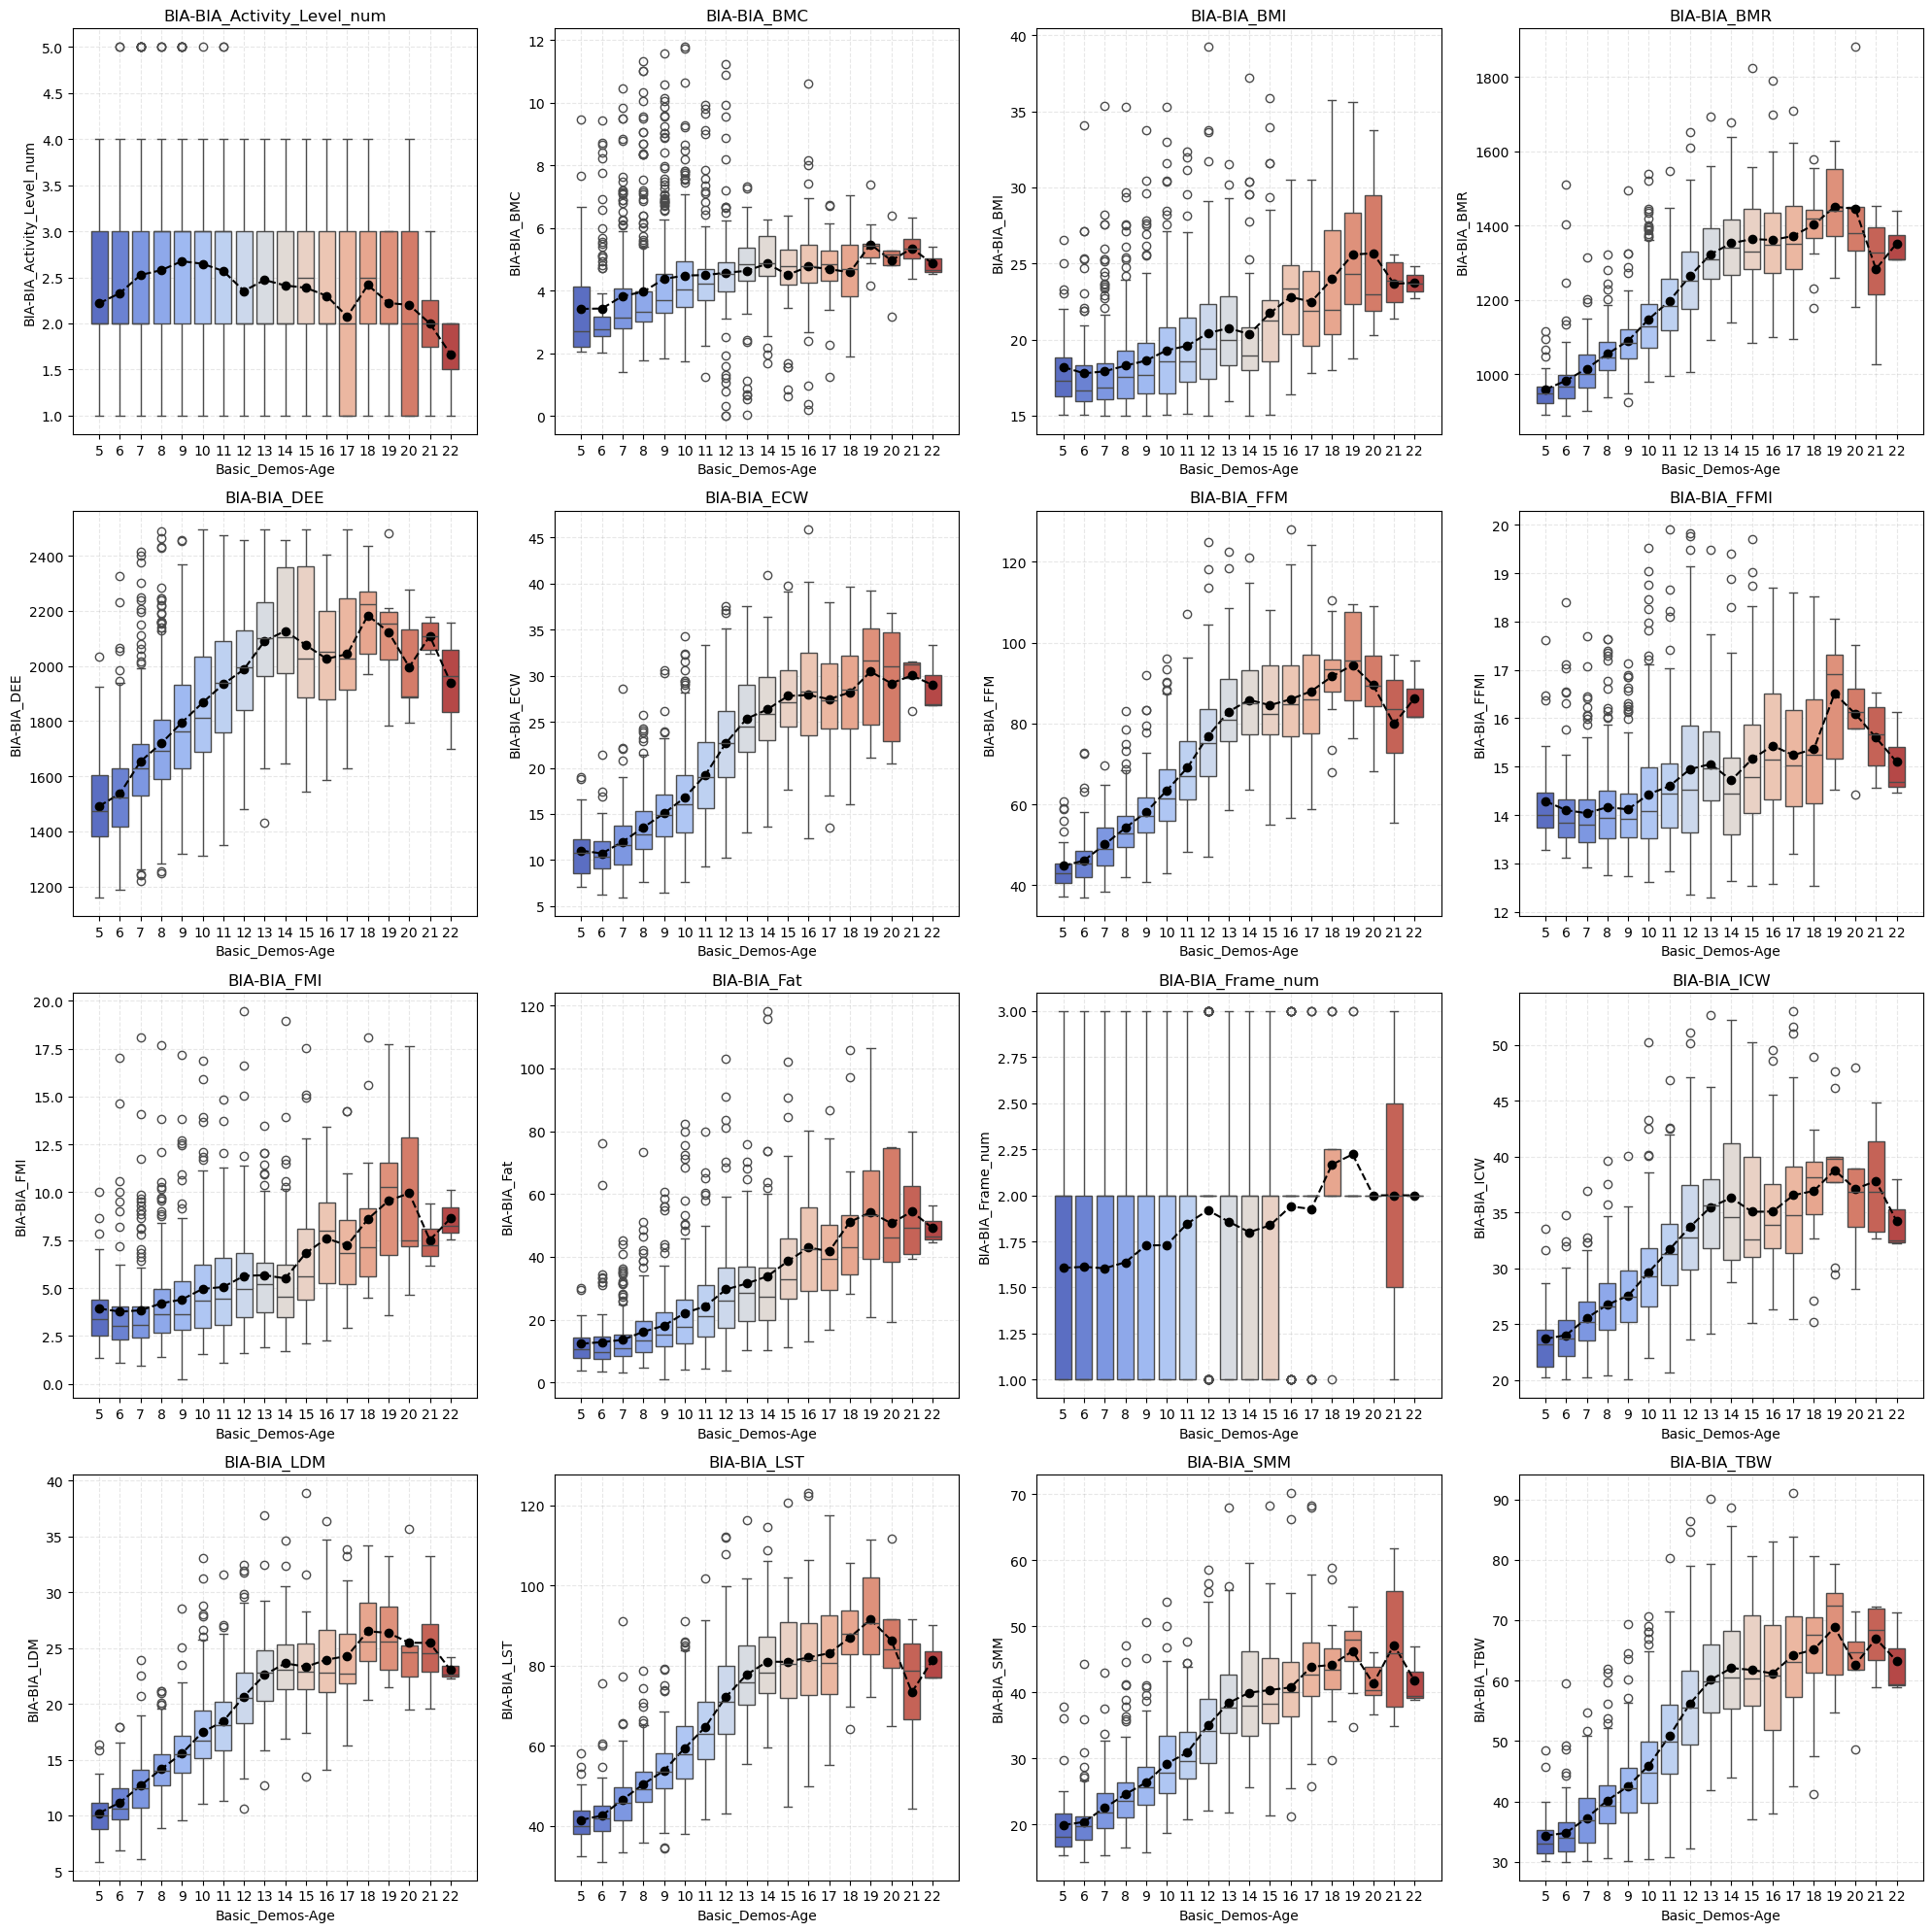

In [ ]:
cols = [
   'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW']

rows = 4
cols_n = 4

fig, ax = plt.subplots(rows, cols_n, figsize=(20, 20))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        x="Basic_Demos-Age",
        y=col,
        data=df,
        ax=ax[i],
        palette="coolwarm"
    )
    means = df.groupby("Basic_Demos-Age")[col].mean()
    ax[i].plot(range(len(means)), means.values, color='black', linestyle='--', marker='o')

    ax[i].set_title(col)
    ax[i].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
import pandas as pd

bins = [5, 8, 11, 14, 18, 21, 23]  # definisce i bordi: [0‑5], [6‑12], [13‑17], [18‑22]
labels = ["5-7", "8-10", "11-13", "14-17", "18-20", "21-23"]

df["AgeGroup"] = pd.cut(
    df["Basic_Demos-Age"],
    bins=bins,
    labels=labels,
    right=False  
)

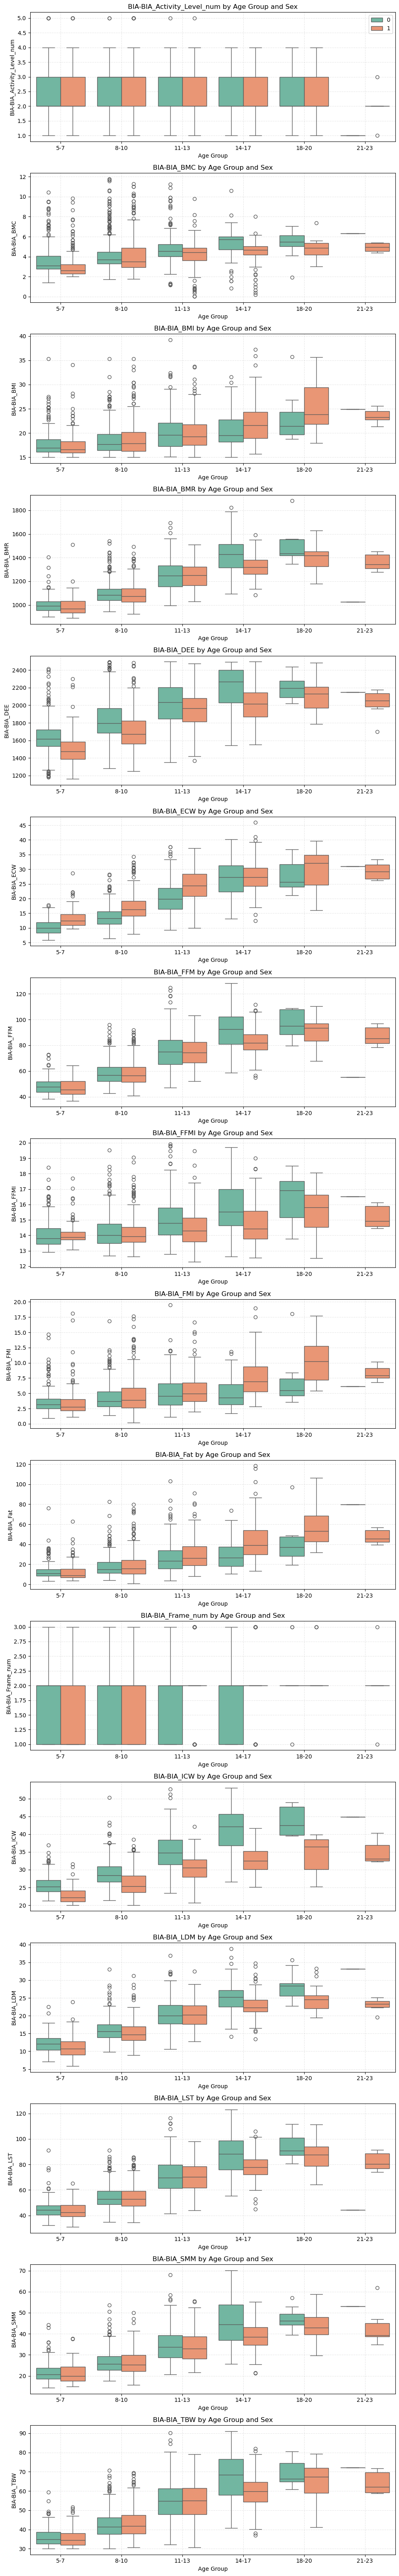

In [64]:
cols = [
   'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW']

fig, axes = plt.subplots(len(cols), 1, figsize=(10, len(cols)*4))

for i, col in enumerate(cols):
    ax = axes[i]
    sns.boxplot(
        x="AgeGroup",
        y=col,
        hue="Basic_Demos-Sex",
        data=df,
        ax=ax,
        palette="Set2"
    )

    ax.set_title(f"{col} by Age Group and Sex")
    ax.set_xlabel("Age Group")
    ax.set_ylabel(col)
    ax.grid(True, linestyle="--", alpha=0.3)
    if i != 0:
        ax.get_legend().remove()
    else:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
num_rows = len(df[(df["Basic_Demos-Sex"] == "Male") & 
                  (df["Basic_Demos-Age"] > 20)])
print(num_rows)

0
